# TakeMeter — Fine-Tuning Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [1]:
import os
from google.colab import userdata
os.environ["USER"] = "jgarcdev"
os.environ["REPO"] = "TakeMeter"
os.environ["TOKEN"] = userdata.get("GITHUB_TOKEN")

%cd /content
!git clone https://${TOKEN}@github.com/${USER}/${REPO}.git
!rm -rf sample_data
%cd /content/{os.environ["REPO"]}


/content
Cloning into 'TakeMeter'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 14 (delta 4), reused 12 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 19.89 KiB | 3.31 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/TakeMeter


In [2]:
# Install any dependencies not pre-installed on Colab
%pip install -q groq # python-dotenv
print("✅ Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 9.8 MB/s eta 0:00:00
✅ Dependencies ready


In [ ]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [4]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
  "lore": 0,
  "build": 1
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'lore': 0, 'build': 1}
Number of labels: 2


In [5]:
CSV_PATH = "/content/TakeMeter/data.csv"

In [6]:
import csv
import pandas as pd
from io import StringIO

# Read the raw CSV content
with open(CSV_PATH, 'r', encoding='utf-8') as f:
  rawLines = f.readlines()

processed_rows = []
# Skip the header row (rawLines[0]) by starting iteration from rawLines[1:]
for i, line in enumerate(rawLines[1:]):
  line = line.strip() # Remove leading/trailing whitespace including newline

  if not line: # Handle empty lines by treating them as two empty fields
    processed_rows.append(['', ''])
    continue

  try:
    # Use csv.reader for robust parsing of quoted fields within a single line
    reader = csv.reader(StringIO(line), delimiter=',', quotechar='"', doublequote=True)
    rowFields = next(reader)

    if len(rowFields) == 2: processed_rows.append(rowFields)
    elif len(rowFields) > 2:
      # If more than 2 fields, assume the extra fields are part of the 'text' column
      # and the last field is the 'label'. This addresses the 'saw 3' error.
      textField = ','.join(rowFields[:-1])
      labelField = rowFields[-1]
      processed_rows.append([textField, labelField])
    else: # len(rowFields) == 1 or 0
      # If only one field, treat it as text and an empty label
      processed_rows.append([rowFields[0] if rowFields else '', ''])

  except csv.Error as e:
    # If csv.reader itself fails (e.g., unescaped quote), the line is heavily malformed.
    print(f"Warning: Heavily malformed line (csv.reader error) at {i+2}: '{line}' -> Error: {e}. Attempting fallback parsing.") # i+2 because we skipped header
    # Fallback: simple split by the last comma to get two parts
    parts = line.rsplit(',', 1)
    if len(parts) == 2: processed_rows.append(parts)
    elif len(parts) == 1: processed_rows.append([parts[0], '']) # Only text, no label
    else: processed_rows.append(['', '']) # Empty line

# Create DataFrame from the processed rows
df = pd.DataFrame(processed_rows, columns=["text", "label"])

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
  print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
  print("Update your LABEL_MAP above to include all labels.")
else: print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label']
Total examples: 200

Label distribution:
label
lore     100
build    100
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [7]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
trainDf, tempDf = train_test_split(df, test_size=0.30, random_state=42, stratify=df["label_id"])
valDf, testDf = train_test_split(tempDf, test_size=0.50, random_state=42, stratify=tempDf["label_id"])

print(f"Train: {len(trainDf)} examples")
print(f"Validation: {len(valDf)} examples")
print(f"Test: {len(testDf)} examples")
print()
print("Train label distribution:")
print(trainDf["label"].value_counts())
print()
print("Test label distribution:")
print(testDf["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
trainDf = trainDf.reset_index(drop=True)
valDf = valDf.reset_index(drop=True)
testDf = testDf.reset_index(drop=True)

Train: 140 examples
Validation: 30 examples
Test: 30 examples

Train label distribution:
label
lore     70
build    70
Name: count, dtype: int64

Test label distribution:
label
lore     15
build    15
Name: count, dtype: int64


In [8]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples): return tokenizer(examples["text"], truncation=True, max_length=256)

def makeDataset(df_split):
  ds = Dataset.from_pandas(df_split[["text", "label_id"]].rename(columns={"label_id": "labels"}))
  return ds.map(tokenize, batched=True)

trainDataset = makeDataset(trainDf)
valDataset = makeDataset(valDf)
testDataset = makeDataset(testDf)

dataCollator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(trainDataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/140 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [13]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS, id2label=ID_TO_LABEL, label2id=LABEL_MAP,)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 2


In [14]:
def computeMetrics(evalPred):
  logits, labels = evalPred
  predictions = np.argmax(logits, axis=-1)

  return {"accuracy": accuracy_score(labels, predictions)}

In [15]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
trainingArgs = TrainingArguments(
  output_dir="./takemeter-model",
  num_train_epochs=3,
  per_device_train_batch_size=16,
  per_device_eval_batch_size=32,
  learning_rate=2e-5,
  weight_decay=0.01,
  warmup_steps=50,
  eval_strategy="epoch",
  save_strategy="epoch",
  save_total_limit=1,
  load_best_model_at_end=True,
  metric_for_best_model="accuracy",
  logging_steps=10,
  report_to="none",
)

trainer = Trainer(
  model=model,
  args=trainingArgs,
  train_dataset=trainDataset,
  eval_dataset=valDataset,
  data_collator=dataCollator,
  compute_metrics=computeMetrics,
)

print("Starting fine-tuning... (5-15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5-15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.682735,0.566667
2,0.689793,0.652567,0.800000
3,0.667227,0.584811,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [16]:
# Run inference on the test set
print("Running inference on test set...")
ftOutput = trainer.predict(testDataset)
ftPredIds = np.argmax(ftOutput.predictions, axis=-1)
ftTrueIds = ftOutput.label_ids

ftProbs = torch.nn.functional.softmax(torch.tensor(ftOutput.predictions), dim=-1).numpy()

# Overall accuracy
ftAccuracy = accuracy_score(ftTrueIds, ftPredIds)
print(f"\n🎯 Fine-tuned model accuracy: {ftAccuracy:.3f}")

# Per-class metrics
labelNames = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ftTrueIds, ftPredIds, target_names=labelNames, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 1.000

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

        lore       1.00      1.00      1.00        15
       build       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



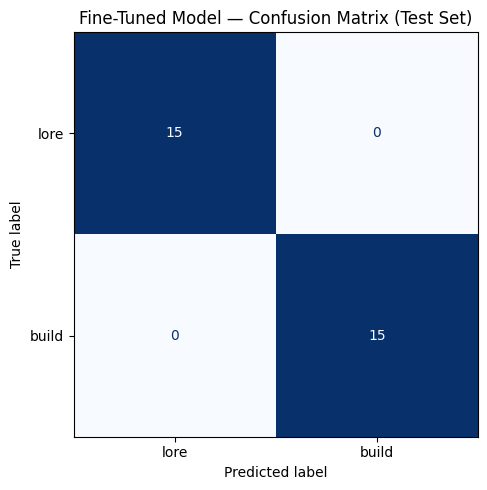

✅ Saved: confusionMatrix.png  →  commit this to your repo and include in README


In [17]:
# Confusion matrix
cm = confusion_matrix(ftTrueIds, ftPredIds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labelNames)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusionMatrix.png", dpi=150)
plt.show()
print("✅ Saved: confusionMatrix.png  →  commit this to your repo and include in README")

In [18]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrongIdx = np.where(ftPredIds != ftTrueIds)[0]
print(f"Wrong predictions: {len(wrongIdx)} / {len(ftTrueIds)}\n")

for i, idx in enumerate(wrongIdx[:15]):
  text = testDf.iloc[idx]["text"]
  trueLabel = ID_TO_LABEL[ftTrueIds[idx]]
  predLabel = ID_TO_LABEL[ftPredIds[idx]]
  confidence = ftProbs[idx][ftPredIds[idx]]
  print(f"--- #{i+1} ---")
  print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
  print(f"True:      {trueLabel}")
  print(f"Predicted: {predLabel}  (confidence: {confidence:.2f})")
  print()

Wrong predictions: 0 / 30



---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [9]:
from groq import Groq

GROQ_API_KEY = userdata.get("GROQ_API_KEY")


client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [10]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are classifying Discord messages from the SoulWorker Discord Server.
Assign each post to exactly one of the following categories.

lore: Discusses the lore of the game, such as character backstories, world-building, and plot details.
Example: "Most DesireWorkers want simple things such as revenge, death, or they simply hate something, they're obsessed with something etc.. Meanwhile SoulWorkers seem to have aspirations that require various hurdles to get there "

build: Provides tips and advice on how to build characters in the game, such as which skills to prioritize, which equipment to use, and how to optimize stats.
Example: "Chainsaw meltdown state buffs damage aoutout substantialy to skill already casted on field"

Respond with ONLY the label name.
Do not explain your reasoning.

Valid labels:
lore
build
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 825 characters


In [11]:
def classifyWithGroq(text):
  """Classify a single post. Returns a label string or None if unparseable."""
  try:
    response = client.chat.completions.create(
      model="llama-3.3-70b-versatile",
      messages=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Classify this post:\n\n{text}"},
      ],
      temperature=0,
      max_tokens=20,
    )
    raw = response.choices[0].message.content.strip().lower()
    # Match the model's output to a label. Check longest labels first so a
    # label that is a substring of another (e.g. "recommendation" vs.
    # "strong_recommendation") can't be matched by mistake.
    for label in sorted(LABEL_MAP, key=len, reverse=True):
      if raw == label or label in raw: return label
    return None  # model output didn't match any known label
  except Exception as e:
    print(f"API error: {e}")
    return None


# Run baseline on test set
print(f"Running baseline on {len(testDf)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baselinePreds = []
for i, (_, row) in enumerate(testDf.iterrows()):
  pred = classifyWithGroq(row["text"])
  baselinePreds.append(pred)
  if (i + 1) % 10 == 0: print(f"  {i+1}/{len(testDf)} complete...")
  time.sleep(0.1)

noneCount = baselinePreds.count(None)
if noneCount > 0:
  print(f"\n⚠️  {noneCount} responses could not be parsed.")
  print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 30 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/30 complete...
  20/30 complete...
  30/30 complete...


In [ ]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baselinePreds, testDf["label_id"]) if p is not None]
blPredIds = [LABEL_MAP[p] for p, _ in valid]
blTrueIds = [t for _, t in valid]

blAccuracy = accuracy_score(blTrueIds, blPredIds)
print(f"🎯 Baseline accuracy: {blAccuracy:.3f}  (evaluated on {len(valid)}/{len(testDf)} parseable responses)")
print()
labelNames = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(blTrueIds, blPredIds, target_names=labelNames, zero_division=0))

🎯 Baseline accuracy: 0.967  (evaluated on 30/30 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

        lore       0.94      1.00      0.97        15
       build       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [ ]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {blAccuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ftAccuracy:>8.3f}")
print("-" * 45)
delta = ftAccuracy - blAccuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.967
Fine-tuned DistilBERT                  1.000
---------------------------------------------

Fine-tuning improvement: 0.033

Use these numbers in your README evaluation report.


In [ ]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
  "baseline_accuracy": round(blAccuracy, 4),
  "finetuned_accuracy": round(ftAccuracy, 4),
  "improvement": round(ftAccuracy - blAccuracy, 4),
  "test_set_size": len(testDf),
  "label_map": LABEL_MAP,
  "model": MODEL_NAME,
}
with open("evaluationResults.json", "w") as f:
  json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluationResults.json  — metrics for your README")
print("   confusionMatrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluationResults.json  — metrics for your README
   confusionMatrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
